# CFA V4 Organization

### Hold Feature Dims - 7 Dims
* X, Y, Px, Py, is_foot, is_pinch, is_flat
### OCH Roles - 5 dims

In [6]:
from climb_conversion import ClimbsFeatureArray
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [4]:
cfa = ClimbsFeatureArray()
display(cfa.climbs_df)

Initializing ClimbsFeatureArray...
ClimbsFeatureArray initialized! 92651 unique climbs added!
Hold feature vector: 7-dim ['x', 'y', 'pull_x', 'pull_y', 'is_foot', 'pinch', 'flat']


,layout_id,angle,holds,grade,quality,ascents
id,,,,,,
00B8F8A461C84A09A9AB1D5844517D92,layout-0aa86d03949f,-0.066667,"[[1136, 0], [1169, 3], [1234, 2], [1253, 2], [...",0.079545,-0.420262,-0.726801
0149efaa214e4a9dbc8b0a4b152127a3,layout-0aa86d03949f,0.200000,"[[1185, 0], [1198, 0], [1219, 3], [1300, 2], [...",0.163636,-0.387460,-0.857715
01ea3efd598d4e07ac53029061745189,layout-0aa86d03949f,-0.066667,"[[1157, 0], [1191, 3], [1203, 2], [1215, 2], [...",-0.090909,-0.593772,-0.919869
020B70C3B5214A72841E3929205C871F,layout-0aa86d03949f,0.200000,"[[1149, 0], [1151, 0], [1183, 2], [1185, 2], [...",-1.000000,-0.070049,-1.000000
079DB25B387E42B38B3DF4CC81CFB9CF,layout-0aa86d03949f,0.200000,"[[1185, 0], [1201, 3], [1202, 0], [1250, 2], [...",0.151518,-0.476286,-1.000000
...,...,...,...,...,...,...
B2FB0269C0E046BAB4A4E1C65B3AFAA6,layout-47aa8b2f3cbc,0.200000,"[[587, 2], [627, 1], [664, 3], [667, 3], [668,...",0.068182,-1.000000,-0.919869
539996B18BD24A2D8841F64BB076A558,layout-47aa8b2f3cbc,0.200000,"[[579, 0], [609, 3], [610, 2], [612, 2], [614,...",-0.454545,-0.070049,-1.000000
3DECB429D2F94B7EBED66149A7D2160F,layout-47aa8b2f3cbc,0.200000,"[[614, 1], [699, 2], [716, 2], [771, 0], [776,...",-0.090909,-1.000000,-1.000000


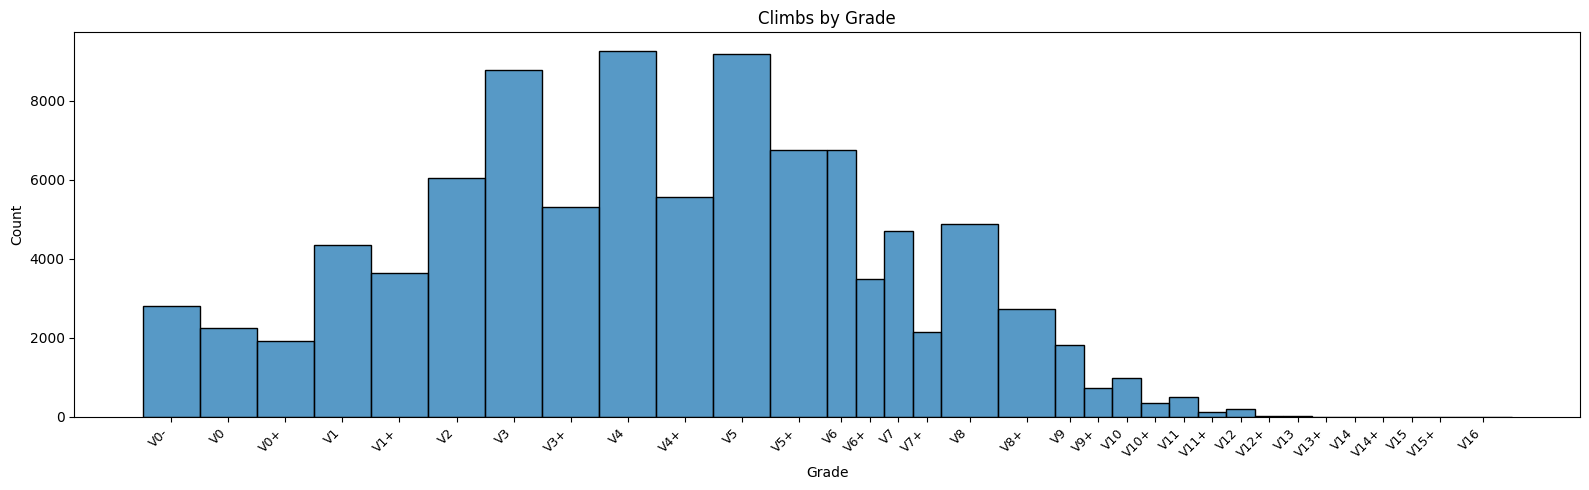

In [13]:
import sqlite3
from diffusion_utils import GRADE_TO_DIFF
with sqlite3.connect("data/storage.db") as conn:
            # Load climbs
            dfc = pd.read_sql_query(
                "SELECT * FROM climbs WHERE ascents > 2", conn, index_col='id'
            )
dfc.head()
grades = list(GRADE_TO_DIFF["v_grade"].keys())
diffs = list(GRADE_TO_DIFF["v_grade"].values())
bins = diffs + [34]  # add a right edge for the last grade
tick_positions = [(bins[i] + bins[i+1]) / 2 for i in range(len(grades))]

fig, ax = plt.subplots(figsize=(16, 5))

sns.histplot(data=dfc, x="grade", bins=bins, ax=ax)

ax.set_xticks(tick_positions)
ax.set_xticklabels(grades, rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Grade")
ax.set_ylabel("Count")
ax.set_title("Climbs by Grade")

plt.tight_layout()
plt.show()